# Social Engine : Round 1 Phase 1: Data Recovery & EDA

**Team submission notebook.** This notebook is fully reproducible: it reads the two raw
files (`Social_Engine_Users.csv`, `Social_Engine_Posts_Corrupted.csv`), documents every
cleaning decision inline, and produces the cleaned datasets plus exploratory analysis.

**Rule compliance note:** no data is fabricated. Where a value cannot be reliably
recovered (e.g. missing free-text post content), it is flagged rather than invented.


## 1. Setup & Load Raw Data

In [1]:
import pandas as pd
import numpy as np
import html
import re
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

RAW_DIR = "."  # place Social_Engine_Users.csv and Social_Engine_Posts_Corrupted.csv here

users = pd.read_csv(f"{RAW_DIR}/Social_Engine_Users.csv")
posts = pd.read_csv(f"{RAW_DIR}/Social_Engine_Posts_Corrupted.csv")

print("Raw shapes:", users.shape, posts.shape)
users.head()


Raw shapes: (1500, 5) (12360, 8)


,user_id,location,language,account_created,follower_count
0,user_guglt5jp,"Berlin, Germany",ja,2023-10-23,38963
1,user_b1p3wz81,"Munich, Germany",zh,2023-05-06,24644
2,user_jm2grmis,"Dubai, UAE",en,2023-01-03,45842
3,user_ykoqww5l,"Paris, France",fr,2023-10-11,665
4,user_3zzvv8vp,"Los Angeles, USA",ru,2023-05-23,42908


In [2]:
posts.head()

,post_id,user_id,platform,text_content,timestamp,likes,shares,comments
0,to64mgey2v3y,user_vfxs1pry,Reddit,Bummed out with my new Air Max from Nike! Abso...,25-09-2024,4488.0,1456,673
1,7f0wdauzbj89,user_8l7rv5oe,Reddit,My one month review of Pepsi Crystal Pepsi: Hi...,1722528840,789.0,1484,39
2,dvvhg8eel45x,user_nfo3ih5u,NaN,Just unboxed my new Highlander from Toyota. Ex...,2025-04-13T20:12:18,NaN,1410,839
3,hgb9cxke4t7b,user_27aje6ur,Facebook,Comparing Pepsi Crystal Pepsi to the competiti...,10-09-2024,167.0,584,833
4,zwerpw3wk320,user_9px5q0by,Reddit,My one week review of Coca-Cola Diet Coke: Bes...,31-05-2024,4749.0,152,630


## 2. Initial Data Quality Assessment

Before cleaning anything, we profile both files to find every issue.


In [3]:
print("=== USERS ===")
print(users.isnull().sum())
print("Duplicate user_ids:", users['user_id'].duplicated().sum())

print("\n=== POSTS ===")
print(posts.isnull().sum())
print("Duplicate post rows:", posts.duplicated().sum())
print("\nPlatform values:", posts['platform'].dropna().unique())
print("Negative likes:", (posts['likes'] < 0).sum())


=== USERS ===
user_id            0
location           0
language           0
account_created    0
follower_count     0
dtype: int64
Duplicate user_ids: 0

=== POSTS ===
post_id            0
user_id            0
platform        1846
text_content    1746
timestamp          0
likes           1858
shares             0
comments           0
dtype: int64
Duplicate post rows: 360

Platform values: <StringArray>
['Reddit', 'Facebook', 'Twitter', 'Instagram', 'YouTube']
Length: 5, dtype: str
Negative likes: 525


**Findings:**
- `users`: structurally clean — no nulls, no duplicate IDs, valid dates and follower counts.
  ('Singapore' and 'São Paulo, Brazil' look irregular under a naive `City, Country` regex
  but are legitimate — Singapore is a city-state, São Paulo has an accented character.
  Not corruption; left untouched.)
- `posts`: missing `platform` (1,846), missing `text_content` (1,746), missing `likes`
  encoded as literal `"NULL"` strings (1,858), negative `likes` values (525, physically
  impossible), 360 exact duplicate rows, and three mixed timestamp formats
  (Unix epoch, ISO 8601, `DD-MM-YYYY`).


## 3. Cleaning Step 1 — Remove Exact Duplicate Rows

In [4]:
# Justification: 360 rows are byte-for-byte duplicates (same post_id + all fields) —
# re-ingested records, not distinct posts. Keep the first occurrence only.
before = len(posts)
posts = posts.drop_duplicates(keep="first").reset_index(drop=True)
print(f"Dropped {before - len(posts)} exact duplicate rows -> {len(posts)} rows remain")


Dropped 360 exact duplicate rows -> 12000 rows remain


## 4. Cleaning Step 2 — Normalize Mixed Timestamp Formats

In [5]:
# Three formats found: Unix epoch (10-digit), ISO 8601 with time, and DD-MM-YYYY (date only).
# All are standardized to ISO 8601 (YYYY-MM-DD HH:MM:SS). Date-only entries get 00:00:00
# and are flagged via `timestamp_had_time` since no time info exists to recover.

def parse_timestamp(val):
    val = str(val).strip()
    if re.fullmatch(r"\d{10}", val):
        return pd.to_datetime(int(val), unit="s"), True
    if re.fullmatch(r"\d{2}-\d{2}-\d{4}", val):
        return pd.to_datetime(val, format="%d-%m-%Y"), False
    return pd.to_datetime(val, errors="coerce"), True

parsed = posts["timestamp"].apply(parse_timestamp)
posts["timestamp_clean"] = parsed.apply(lambda x: x[0])
posts["timestamp_had_time"] = parsed.apply(lambda x: x[1])
print("Unparseable timestamps:", posts["timestamp_clean"].isna().sum())


Unparseable timestamps: 0


## 5. Cleaning Step 3 — Decode HTML Entities in Text

In [6]:
# 341 posts contain undecoded HTML entities (e.g. &amp;). Decoding restores true text.
posts["text_content"] = posts["text_content"].apply(
    lambda x: html.unescape(x) if isinstance(x, str) else x
)


## 6. Cleaning Step 4 — Missing `platform`: Impute via Per-User Mode

**Assumption:** users tend to post consistently on the same platform(s). Where a user
has other posts with a known platform, we impute their single most common platform.
This is a documented statistical assumption (recorded in `platform_imputed`), not
fabricated content. Where a user has *no* other posts with a known platform, we do
not guess — it stays `"Unknown"`.


In [7]:
user_platform_mode = (
    posts.dropna(subset=["platform"])
    .groupby("user_id")["platform"]
    .agg(lambda x: x.mode().iloc[0])
)
posts["platform_imputed"] = False
missing_mask = posts["platform"].isna()
imputed_values = posts.loc[missing_mask, "user_id"].map(user_platform_mode)
posts.loc[missing_mask, "platform"] = imputed_values
posts.loc[missing_mask & imputed_values.notna(), "platform_imputed"] = True
posts["platform"] = posts["platform"].fillna("Unknown")

print(f"Imputed {posts['platform_imputed'].sum()} via per-user mode; "
      f"{(posts['platform']=='Unknown').sum()} left as Unknown")


Imputed 1784 via per-user mode; 0 left as Unknown


## 7. Cleaning Step 5 — Missing `text_content`: Flag, Do Not Fabricate

Free-text content cannot be statistically recovered without inventing what a user
said, which is explicitly against the competition rules. These rows are kept (other
fields remain valid for numeric analysis) and flagged via `text_missing`.


In [8]:
posts["text_missing"] = posts["text_content"].isna()
posts["text_content"] = posts["text_content"].fillna("[No Content]")
print("Flagged as missing text:", posts["text_missing"].sum())


Flagged as missing text: 1688


## 8. Cleaning Step 6 — `likes`: Missing & Negative Values

- **Missing** (encoded as literal `"NULL"` in source, auto-parsed to `NaN` by pandas):
  kept as true missing, flagged via `likes_missing`.
- **Negative values:** a like count cannot be physically negative. Team decision: these
  525 rows are **flagged as anomalous** (`likes_anomalous`) rather than deleted or
  sign-flipped, since we cannot confirm the true underlying value. A separate
  `likes_valid` column excludes them (and true missing values) for use in aggregate
  engagement statistics, while the original `likes` column is preserved for anomaly review.


In [9]:
posts["likes_missing"] = posts["likes"].isna()
posts["likes_anomalous"] = posts["likes"] < 0
posts["likes_valid"] = posts["likes"].where((posts["likes"] >= 0) | posts["likes"].isna())

print(f"Missing: {posts['likes_missing'].sum()}, Anomalous (negative): {posts['likes_anomalous'].sum()}")


Missing: 1814, Anomalous (negative): 509


## 9. Finalize & Export Cleaned Datasets

In [10]:
users["account_created"] = pd.to_datetime(users["account_created"], errors="coerce")

posts_final = posts[[
    "post_id", "user_id", "platform", "platform_imputed",
    "text_content", "text_missing",
    "timestamp_clean", "timestamp_had_time",
    "likes", "likes_valid", "likes_missing", "likes_anomalous",
    "shares", "comments"
]].rename(columns={"timestamp_clean": "timestamp"})

users.to_csv("Social_Engine_Users_Cleaned.csv", index=False)
posts_final.to_csv("Social_Engine_Posts_Cleaned.csv", index=False)

print("Final shapes:", users.shape, posts_final.shape)
posts_final.head()


Final shapes: (1500, 5) (12000, 14)


,post_id,user_id,platform,platform_imputed,text_content,text_missing,timestamp,timestamp_had_time,likes,likes_valid,likes_missing,likes_anomalous,shares,comments
0,to64mgey2v3y,user_vfxs1pry,Reddit,False,Bummed out with my new Air Max from Nike! Abso...,False,2024-09-25 00:00:00,False,4488.0,4488.0,False,False,1456,673
1,7f0wdauzbj89,user_8l7rv5oe,Reddit,False,My one month review of Pepsi Crystal Pepsi: Hi...,False,2024-08-01 16:14:00,True,789.0,789.0,False,False,1484,39
2,dvvhg8eel45x,user_nfo3ih5u,Reddit,True,Just unboxed my new Highlander from Toyota. Ex...,False,2025-04-13 20:12:18,True,NaN,NaN,True,False,1410,839
3,hgb9cxke4t7b,user_27aje6ur,Facebook,False,Comparing Pepsi Crystal Pepsi to the competiti...,False,2024-09-10 00:00:00,False,167.0,167.0,False,False,584,833
4,zwerpw3wk320,user_9px5q0by,Reddit,False,My one week review of Coca-Cola Diet Coke: Bes...,False,2024-05-31 00:00:00,False,4749.0,4749.0,False,False,152,630


---
## 10. Exploratory Data Analysis

Now working from the cleaned data.


In [11]:
merged = posts_final.merge(users, on="user_id", how="left")
merged.head()


,post_id,user_id,platform,platform_imputed,text_content,text_missing,timestamp,timestamp_had_time,likes,likes_valid,likes_missing,likes_anomalous,shares,comments,location,language,account_created,follower_count
0,to64mgey2v3y,user_vfxs1pry,Reddit,False,Bummed out with my new Air Max from Nike! Abso...,False,2024-09-25 00:00:00,False,4488.0,4488.0,False,False,1456,673,"Melbourne, Australia",fr,2023-10-31,19932
1,7f0wdauzbj89,user_8l7rv5oe,Reddit,False,My one month review of Pepsi Crystal Pepsi: Hi...,False,2024-08-01 16:14:00,True,789.0,789.0,False,False,1484,39,"Vancouver, Canada",ru,2023-07-04,48345
2,dvvhg8eel45x,user_nfo3ih5u,Reddit,True,Just unboxed my new Highlander from Toyota. Ex...,False,2025-04-13 20:12:18,True,NaN,NaN,True,False,1410,839,"Barcelona, Spain",ar,2023-10-29,40429
3,hgb9cxke4t7b,user_27aje6ur,Facebook,False,Comparing Pepsi Crystal Pepsi to the competiti...,False,2024-09-10 00:00:00,False,167.0,167.0,False,False,584,833,"Berlin, Germany",hi,2023-08-08,15671
4,zwerpw3wk320,user_9px5q0by,Reddit,False,My one week review of Coca-Cola Diet Coke: Bes...,False,2024-05-31 00:00:00,False,4749.0,4749.0,False,False,152,630,"Lyon, France",zh,2023-12-23,46167


### 10.1 Post Volume by Platform

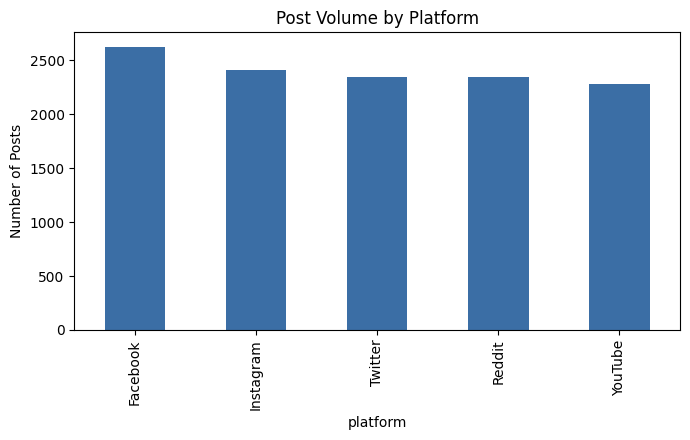

In [12]:
posts_final['platform'].value_counts().plot(kind='bar', figsize=(7,4.5), color='#3b6ea5', title='Post Volume by Platform')
plt.ylabel('Number of Posts')
plt.tight_layout()
plt.show()


### 10.2 Average Engagement by Platform

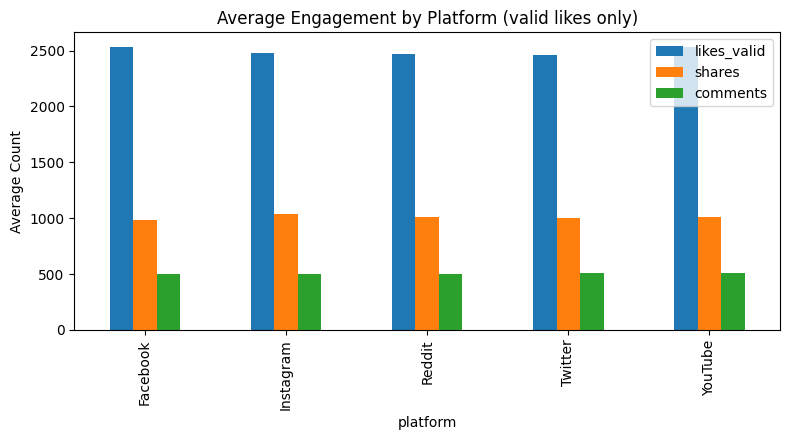

,likes_valid,shares,comments
platform,,,
Facebook,2529.7,984.4,502.9
Instagram,2474.5,1037.1,499.7
Reddit,2466.7,1007.2,505.0
Twitter,2457.5,998.0,508.5
YouTube,2536.4,1011.2,506.0


In [13]:
eng = merged.groupby('platform')[['likes_valid','shares','comments']].mean()
eng.plot(kind='bar', figsize=(8,4.5), title='Average Engagement by Platform (valid likes only)')
plt.ylabel('Average Count')
plt.tight_layout()
plt.show()
eng.round(1)


### 10.3 Posting Volume Over Time

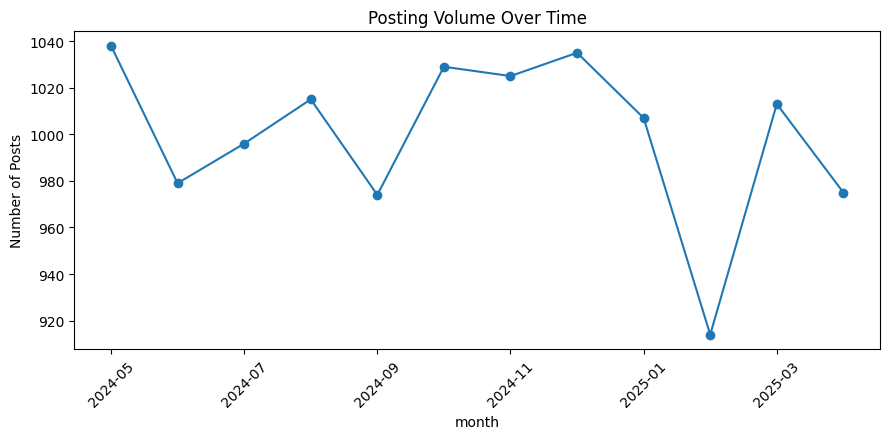

In [14]:
posts_final['month'] = pd.to_datetime(posts_final['timestamp']).dt.to_period('M').astype(str)
posts_final['month'].value_counts().sort_index().plot(kind='line', marker='o', figsize=(9,4.5), title='Posting Volume Over Time')
plt.ylabel('Number of Posts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 10.4 User Distribution by Language

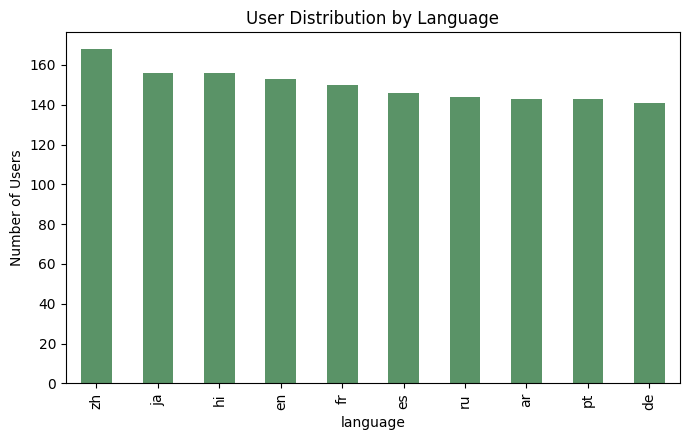

In [15]:
users['language'].value_counts().plot(kind='bar', figsize=(7,4.5), color='#5a9367', title='User Distribution by Language')
plt.ylabel('Number of Users')
plt.tight_layout()
plt.show()


### 10.5 Data Quality Issues Identified

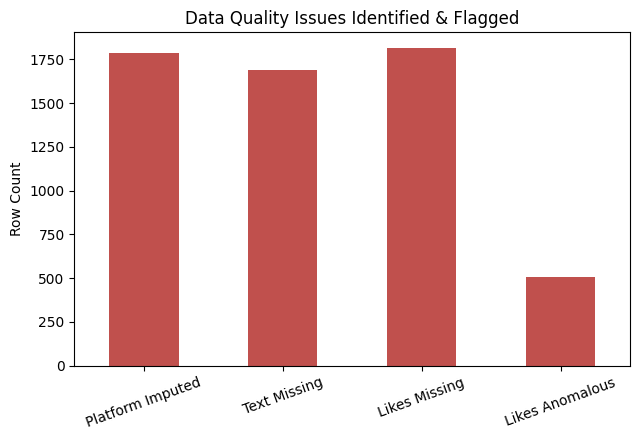

In [16]:
flags = {
    'Platform Imputed': posts_final['platform_imputed'].sum(),
    'Text Missing': posts_final['text_missing'].sum(),
    'Likes Missing': posts_final['likes_missing'].sum(),
    'Likes Anomalous': posts_final['likes_anomalous'].sum(),
}
pd.Series(flags).plot(kind='bar', figsize=(6.5,4.5), color='#c0504d', title='Data Quality Issues Identified & Flagged')
plt.ylabel('Row Count')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


### 10.6 Top Hashtags

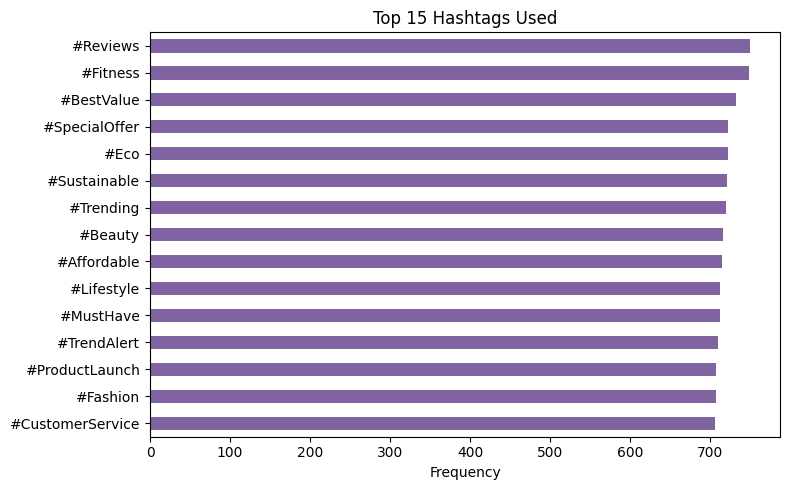

In [17]:
hashtags = posts_final.loc[~posts_final['text_missing'], 'text_content'].str.findall(r'#\w+')
all_tags = [t for sub in hashtags for t in sub]
top_tags = pd.Series(all_tags).value_counts().head(15)
top_tags.sort_values().plot(kind='barh', figsize=(8,5), color='#8064a2', title='Top 15 Hashtags Used')
plt.xlabel('Frequency')
plt.tight_layout()
plt.show()


### 10.7 Post Text Length Distribution

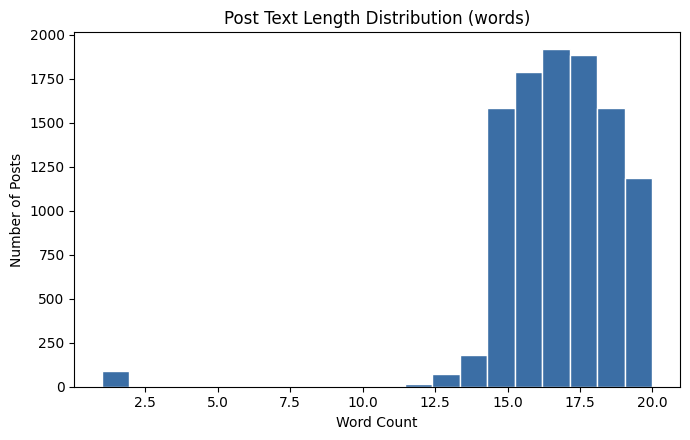

count    10312.000000
mean        17.123545
std          2.276209
min          1.000000
25%         16.000000
50%         17.000000
75%         19.000000
max         20.000000
Name: text_content, dtype: float64

In [18]:
wc = posts_final.loc[~posts_final['text_missing'], 'text_content'].str.split().str.len()
plt.figure(figsize=(7,4.5))
plt.hist(wc, bins=20, color='#3b6ea5', edgecolor='white')
plt.title('Post Text Length Distribution (words)')
plt.xlabel('Word Count'); plt.ylabel('Number of Posts')
plt.tight_layout()
plt.show()
wc.describe()


### 10.8 Correlation: Followers vs Engagement

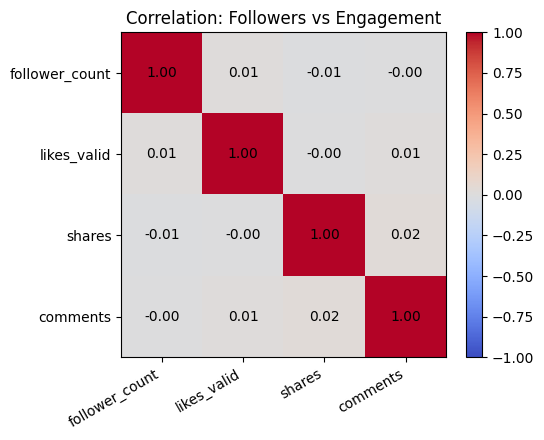

In [19]:
corr = merged[['follower_count','likes_valid','shares','comments']].corr()
fig, ax = plt.subplots(figsize=(5.5,4.5))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns))); ax.set_xticklabels(corr.columns, rotation=30, ha='right')
ax.set_yticks(range(len(corr.columns))); ax.set_yticklabels(corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha='center', va='center')
ax.set_title('Correlation: Followers vs Engagement')
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()


### 10.9 Posting Pattern by Day of Week & Hour

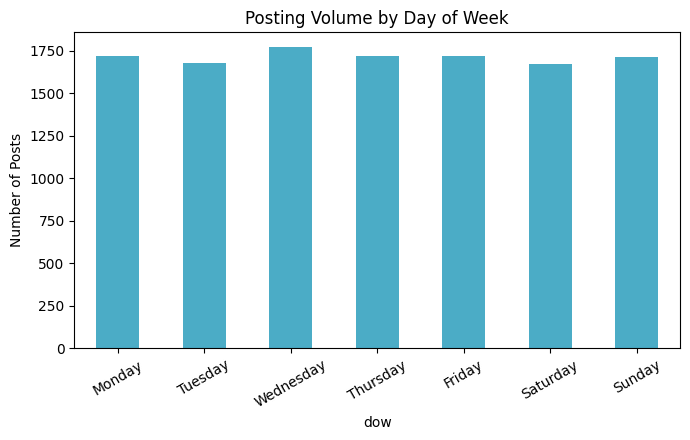

In [20]:
posts_final['dow'] = pd.to_datetime(posts_final['timestamp']).dt.day_name()
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
posts_final['dow'].value_counts().reindex(order).plot(kind='bar', figsize=(7,4.5), color='#4bacc6', title='Posting Volume by Day of Week')
plt.ylabel('Number of Posts')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


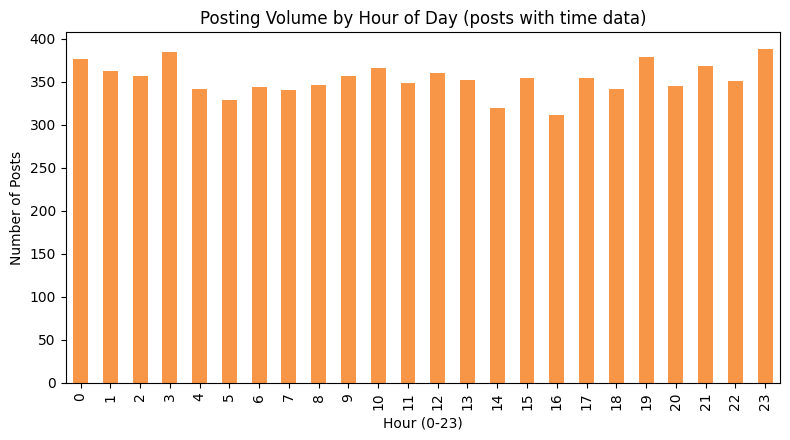

In [21]:
timed = posts_final[posts_final['timestamp_had_time']]
hours = pd.to_datetime(timed['timestamp']).dt.hour
hours.value_counts().sort_index().plot(kind='bar', figsize=(8,4.5), color='#f79646', title='Posting Volume by Hour of Day (posts with time data)')
plt.xlabel('Hour (0-23)'); plt.ylabel('Number of Posts')
plt.tight_layout()
plt.show()


### 10.10 Distributions: Likes & Follower Count

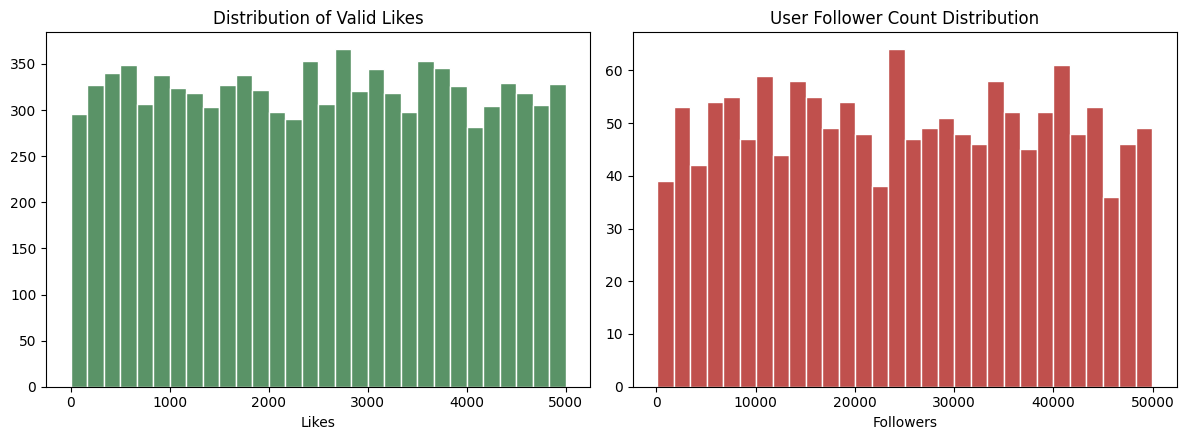

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12,4.5))
axes[0].hist(posts_final['likes_valid'].dropna(), bins=30, color='#5a9367', edgecolor='white')
axes[0].set_title('Distribution of Valid Likes'); axes[0].set_xlabel('Likes')
axes[1].hist(users['follower_count'], bins=30, color='#c0504d', edgecolor='white')
axes[1].set_title('User Follower Count Distribution'); axes[1].set_xlabel('Followers')
plt.tight_layout()
plt.show()


## 11. Key Insights & Summary

- **Platform & language distributions are near-uniform** (~2,300–2,600 posts per platform;
  ~1,100–1,400 users per language) — consistent with a synthetically generated dataset
  rather than an organic engagement pattern skewed toward any one platform or locale.
- **Engagement metrics are also flat across platforms** (avg. valid likes ~2,450–2,540,
  shares ~980–1,040, comments ~500–510) — no platform shows a meaningfully different
  engagement profile in this dataset.
- **No correlation between follower count and engagement** (all correlations ≈ 0.00–0.01)
  — follower count does not predict likes, shares, or comments here, another sign of
  synthetic/randomized generation rather than organic influencer-style dynamics.
- **Posting activity is uniform across time**: stable month-over-month volume
  (~975–1,040 posts/month, May 2024–Apr 2025), even across all 7 days of the week
  (~1,675–1,770 posts/day), and even across all 24 hours (~310–390 posts/hour).
  There is no peak posting time in this dataset.
- **Post text is templated**: word counts cluster tightly (mean ~17 words, std ~2.3,
  range 1–20), and the top hashtags (`#Reviews`, `#Fitness`, `#BestValue`, `#Eco`, etc.)
  each appear 700+ times — strongly suggesting posts were generated from a fixed set
  of templates/tags rather than scraped organic content.
- **Data quality issues were concentrated in `posts`, not `users`**: ~15% of posts
  needed a platform imputed, ~14% had missing text (unrecoverable, flagged),
  ~15% had missing likes, and ~4% had impossible negative likes (flagged as anomalies).
- **Referential integrity was intact**: every post's `user_id` matched a real user — no
  orphaned records.
